# Preprocessing

In [1]:
import numpy as np
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
import seaborn as sns

In [3]:
# import scvi

In [4]:
INPUT_FILE = '/home/ubuntu/data/frangieh/rna.h5ad'

In [5]:
adata = ad.read_h5ad(INPUT_FILE)

In [6]:
print('Number of Cells:', adata.n_obs)
print('Number of Genes:', adata.n_vars)

Number of Cells: 218331
Number of Genes: 23712


In [7]:
# adata.layers['counts'] = adata.X

In [8]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [9]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

In [10]:
adata

AnnData object with n_obs × n_vars = 218331 × 23712
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

## Outlier filtering

In [11]:
def outlier_func(adata_object, metric:str, nmads: int, print_tresholds=False):
    
    metric_median = np.median(adata_object.obs[metric])
    metric_mad = np.median(np.absolute(adata_object.obs[metric] - metric_median))
    upper_T = metric_median + (nmads*metric_mad)
    lower_T = metric_median - (nmads*metric_mad)
    
    if print_tresholds:
        print('upper: ', upper_T)
        print('lower: ', lower_T)

    return (adata_object.obs[metric] > upper_T) |(adata_object.obs[metric] < lower_T)

In [12]:
def qc_plots(adata):
    sc.pl.violin(
    adata,
    ["total_counts", "log1p_total_counts"],
    jitter=0.4,
    multi_panel=True,
    )
    sc.pl.violin(
    adata,
    ["n_genes_by_counts",  "log1p_n_genes_by_counts"],
    jitter=0.4,
    multi_panel=True,
    )
    sc.pl.violin(
    adata,
    ['pct_counts_mt','pct_counts_in_top_50_genes'],
    jitter=0.4,
    multi_panel=True,
    )

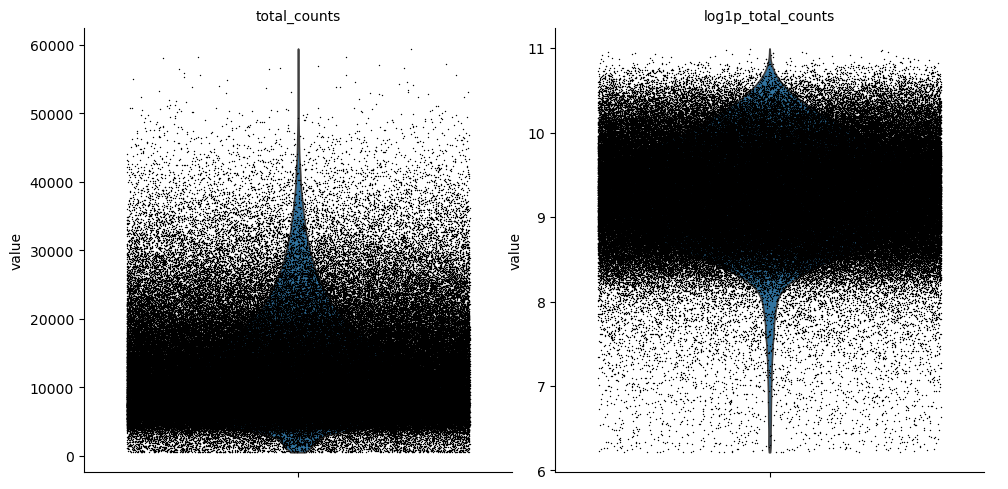

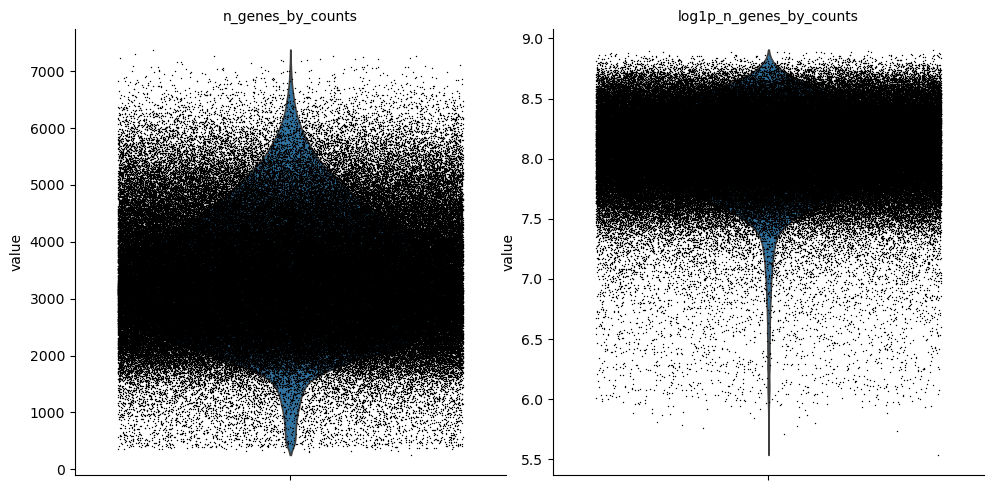

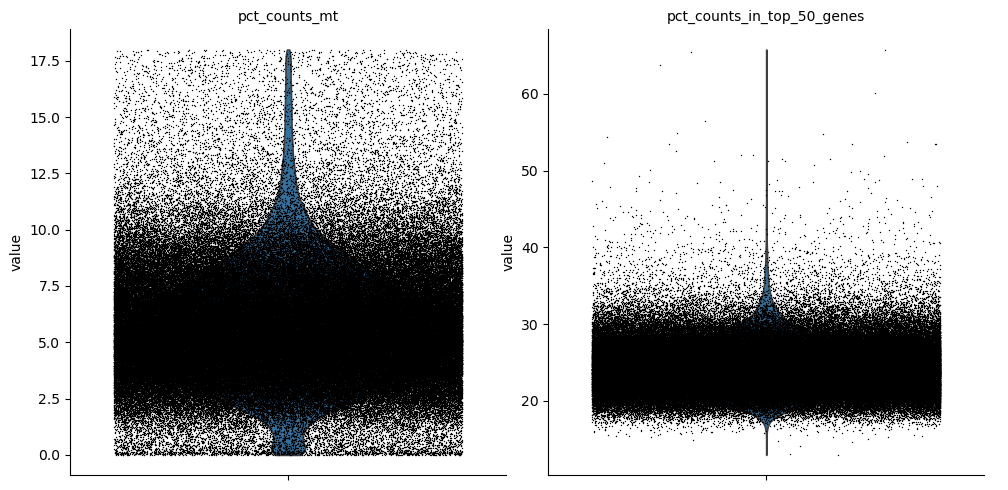

In [13]:
qc_plots(adata)

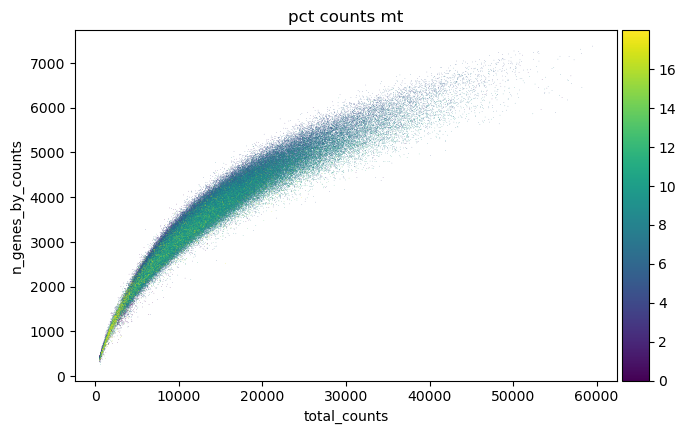

In [14]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

**Notes:** Looking at the AnnData object, we have 218 331 Cells. Due to the high number of available cells, we could afford to be more strict with our filtering.


* `pct_counts_mt`: we can see, that all cells over a thershold of 18 have already been filtered.
* `tota_counts` and `n_genes_by_counts`: There are still some outliers noticable
* `log1p_total_counts`, `log1p_n_genes_by_counts`, `pct_counts_in_top_50_genes`: There are still some outliers noticable



### Min Cells and Genes filters 

In [15]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=20)

In [16]:
adata.shape

(218331, 22097)

### QC Metrics

In [17]:
T = 3
adata.obs['outlier'] = (outlier_func(adata, 'total_counts', T) | 
                       outlier_func(adata, 'log1p_total_counts', T) |
                       outlier_func(adata, 'n_genes_by_counts', T) |
                       outlier_func(adata, 'log1p_n_genes_by_counts', T) |
                       outlier_func(adata, 'pct_counts_mt', T) |
                       outlier_func(adata, 'pct_counts_in_top_50_genes', T))

In [18]:
adata.obs['outlier'].value_counts()

outlier
False    176242
True      42089
Name: count, dtype: int64

In [19]:
adata = adata[~adata.obs['outlier'], :].copy()
adata

AnnData object with n_obs × n_vars = 176242 × 22097
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'outlier'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

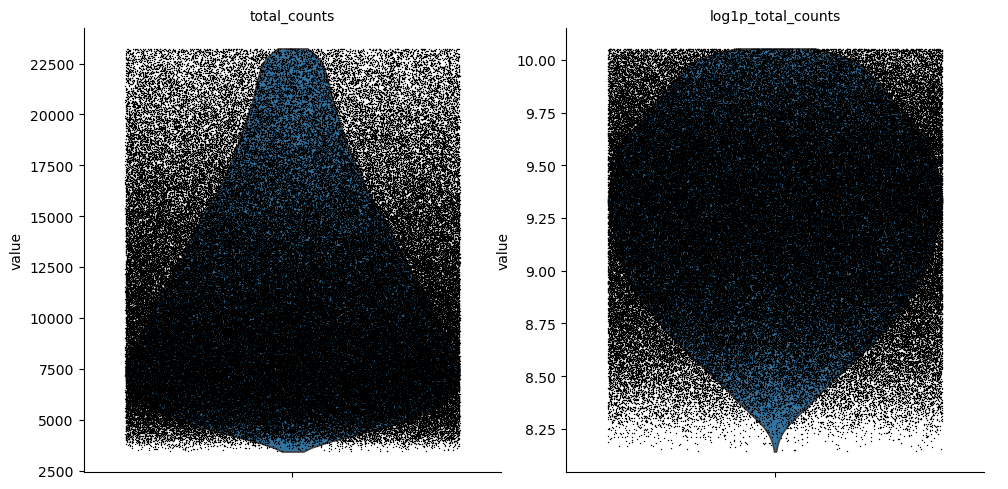

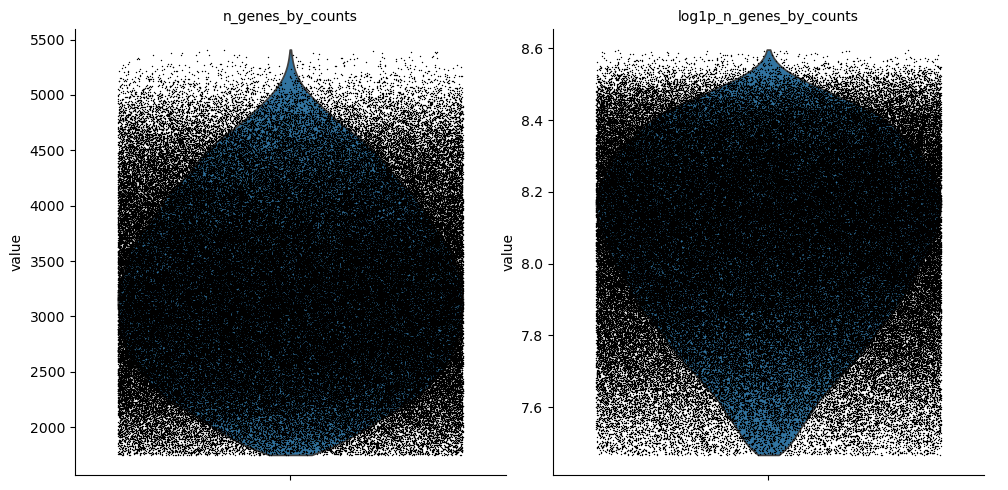

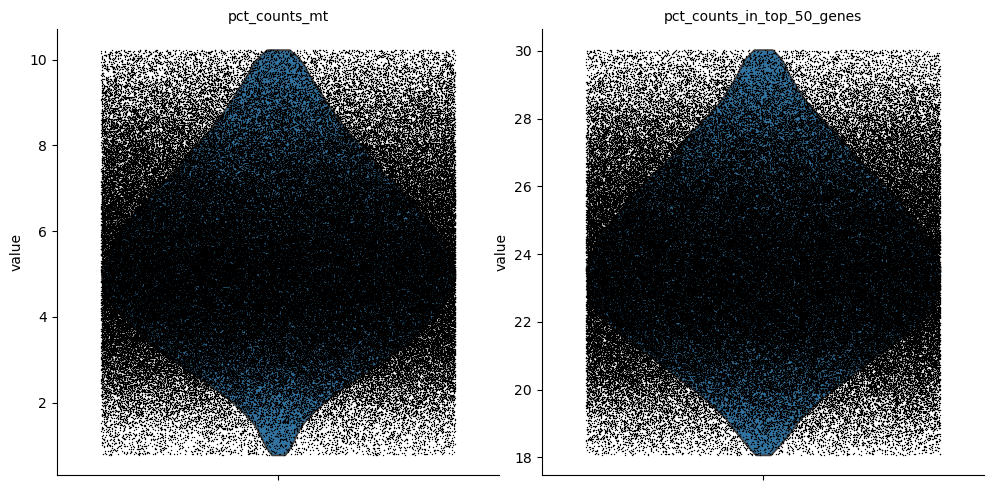

In [20]:
qc_plots(adata)

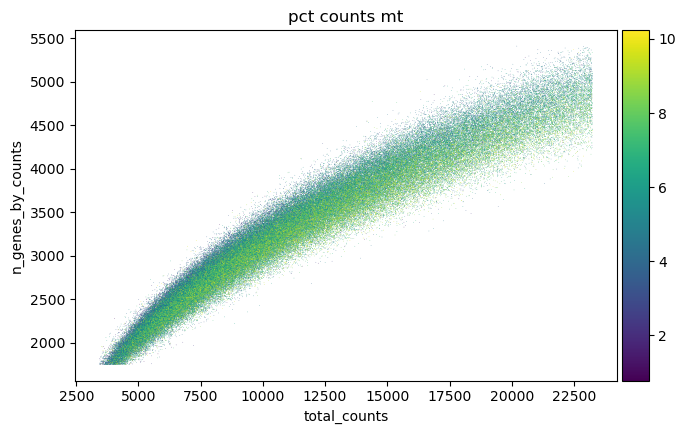

In [21]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

## Doublet Detection

In [22]:
# adata.shape

In [23]:
# adata.obs['perturbation_2'].value_counts()

In [24]:
# adata.obs['doublet_score'] = np.zeros(adata.n_obs)
# adata.obs['predicted_doublet'] = np.zeros(adata.n_obs, dtype=bool)

In [25]:
# i = 0
# loop = 0
# step = 50000
# while i < adata.n_obs:
#     print('Loop',loop)
#     i += step
#     if i > adata.n_obs:
#         i = adata.n_obs
#     subset = adata[(i-step):i].copy()
#     print('Running scrublet')
#     sc.pp.scrublet(subset)
#     print(subset.obs['predicted_doublet'].value_counts())
#     adata[(i-step):i].obs.loc[:, ['doublet_score', 'predicted_doublet']] = subset.obs[['doublet_score', 'predicted_doublet']]
#     loop += 1

In [26]:
# subset = 0

In [27]:
# adata.obs['predicted_doublet'].value_counts()

## Normalization

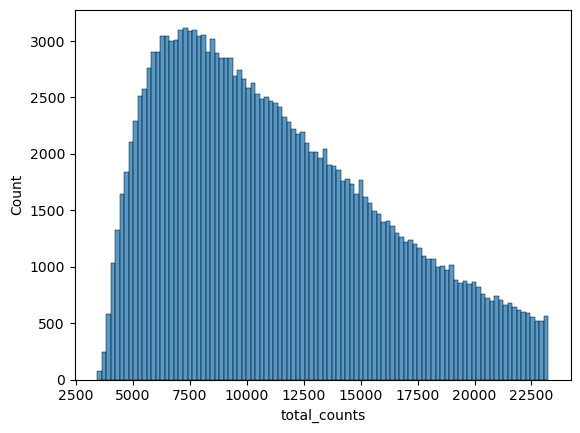

In [28]:
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False)

In [29]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [30]:
# Normalizing to median total counts
sc.pp.normalize_total(adata, target_sum=1e4)
# Logarithmize the data
sc.pp.log1p(adata)

In [31]:
adata

AnnData object with n_obs × n_vars = 176242 × 22097
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'outlier'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p'
    layers: 'counts'

## Highly Variable genes

In [32]:
sc.pp.highly_variable_genes(adata, n_top_genes=200)

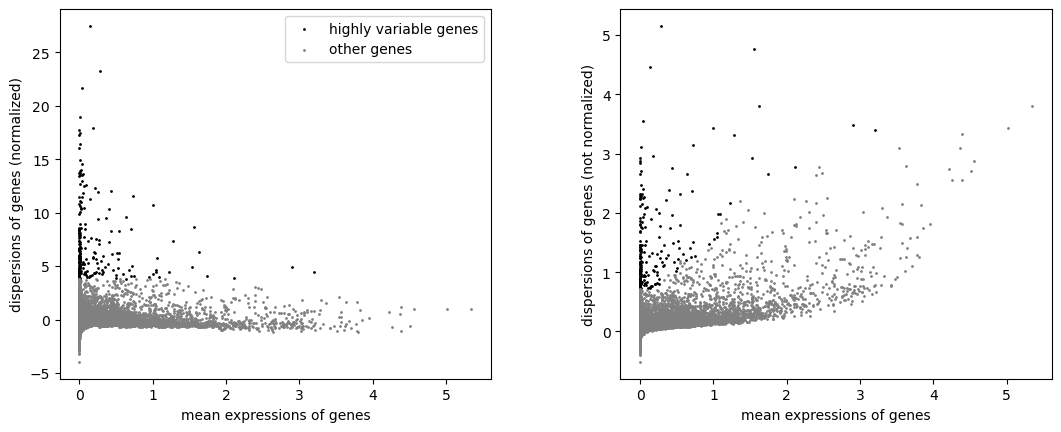

In [33]:
sc.pl.highly_variable_genes(adata)

In [34]:
adata.var

,ensembl_id,ncounts,ncells,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,highly_variable,means,dispersions,dispersions_norm
gene_symbol,,,,,,,,,,,,,,,,,
A1BG,ENSG00000121410,41265.0,34705,False,False,False,34705,0.189002,0.173114,84.104410,41265.0,10.627794,34705,False,0.133132,0.106646,-0.039787
A1BG-AS1,ENSG00000268895,13133.0,12463,False,False,False,12463,0.060152,0.058412,94.291695,13133.0,9.482960,12463,False,0.045112,0.067628,-0.286588
A1CF,ENSG00000148584,114.0,114,False,False,False,114,0.000522,0.000522,99.947786,114.0,4.744932,114,False,0.000459,0.053720,-0.374561
A2M,ENSG00000175899,219.0,193,False,False,False,193,0.001003,0.001003,99.911602,219.0,5.393628,193,False,0.000837,0.205254,0.583949
A2M-AS1,ENSG00000245105,62.0,62,False,False,False,62,0.000284,0.000284,99.971603,62.0,4.143135,62,False,0.000202,-0.065323,-1.127556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZXDC,ENSG00000070476,15389.0,14589,False,False,False,14589,0.070485,0.068112,93.317944,15389.0,9.641473,14589,False,0.053749,0.052662,-0.381257
ZYG11A,ENSG00000203995,113.0,113,False,False,False,113,0.000518,0.000517,99.948244,113.0,4.736198,113,False,0.000319,-0.235811,-2.205961
ZYG11B,ENSG00000162378,28889.0,26025,False,False,False,26025,0.132317,0.124266,88.080025,28889.0,10.271251,26025,False,0.100020,0.081563,-0.198447


## Dimensionality Reduction and Clustering

In [35]:
# sc.tl.pca(adata)

In [36]:
# sc.pl.pca(
#     adata,
#     color=["total_counts", "total_counts", "pct_counts_mt", "pct_counts_mt", "perturbation_2", "perturbation_2"],
#     dimensions=[(0, 1), (2, 3), (0, 1), (2, 3), (0, 1), (2, 3)],
#     ncols=2,
#     size=2,
# )

In [37]:
# sc.pp.neighbors(adata)
# sc.tl.umap(adata)

In [38]:
# sc.pl.umap(
#     adata,
#     color=["total_counts", "n_genes", "perturbation_2"],
#     # Setting a smaller point size to get prevent overlap
#     size=2,
#     cmap="YlGnBu",
#     ncols=2
# )

In [39]:
# sc.tl.leiden(adata)

In [40]:
# sc.pl.umap(
#     adata,
#     color=["perturbation_2", "leiden"],
#     # Setting a smaller point size to get prevent overlap
#     size=2,
#     ncols=1,
# )

## Write processed file

In [41]:
adata.write_h5ad('/home/ubuntu/data/frangieh/rna.qc.hvg200.h5ad')